In [ ]:
# from tensorflow.keras.models import load_model

# model = load_model("word2vec_model.keras")

In [2]:
import pickle
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.manifold import TSNE
from sklearn.preprocessing import normalize
import matplotlib.pyplot as plt

In [ ]:
with open(r"C:\Users\HP\Desktop\Bacancy\AI_ML\Deep_Learning\NLP\Task2\Outputs\embeddings1.pkl", "rb") as f:
    data = pickle.load(f)

embeddings = data["embeddings"]
word2idx = data["word2idx"]
idx2word = data["idx2word"]

## USAGE OF IT

In [ ]:
def get_top_similar_words(word, top_n=5):
    if word not in word2idx:
        return f"'{word}' not in vocabulary"

    word_vec = embeddings[word2idx[word]].reshape(1, -1)

    similarities = cosine_similarity(word_vec, embeddings)[0]

    similar_indices = similarities.argsort()[::-1][1:top_n+1]

    results = []
    for idx in similar_indices:
        results.append((idx2word[idx], similarities[idx]))

    return results

In [4]:
print(get_top_similar_words("harry", top_n=5))

[('ron', np.float32(0.6428385)), ('hermione', np.float32(0.60151386)), ('dumbledore', np.float32(0.51726735)), ('back', np.float32(0.51570445)), ('looked', np.float32(0.4949686))]


## SIMILARITY BETWEEN 2 WORDS

In [5]:
def get_similarity(word1, word2):
    if word1 not in word2idx or word2 not in word2idx:
        return "One or both words not in vocabulary"

    vec1 = embeddings[word2idx[word1]].reshape(1, -1)
    vec2 = embeddings[word2idx[word2]].reshape(1, -1)

    sim = cosine_similarity(vec1, vec2)[0][0]
    return sim

In [23]:
print("Similarity:", get_similarity("harry", "prejudiced"))

Similarity: -0.021170553


## PLOT WORDS

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.preprocessing import normalize

def plot_specific_words(words):
    valid_words = []
    vectors = []

    for word in words:
        if word in word2idx:
            valid_words.append(word)
            vectors.append(embeddings[word2idx[word]])
        else:
            print(f"'{word}' not in vocabulary")

    if len(vectors) < 2:
        print("Need at least 2 valid words to plot")
        return

    X = np.array(vectors)

    X = normalize(X)

    tsne = TSNE(n_components=2, perplexity=min(5, len(X)-1), random_state=42)
    X_2d = tsne.fit_transform(X)

    plt.figure(figsize=(8, 6))
    plt.scatter(X_2d[:, 0], X_2d[:, 1])

    for i, word in enumerate(valid_words):
        plt.text(X_2d[i, 0], X_2d[i, 1], word, fontsize=12)

    plt.title("t-SNE Plot for Selected Words")
    plt.grid(True)
    plt.show()

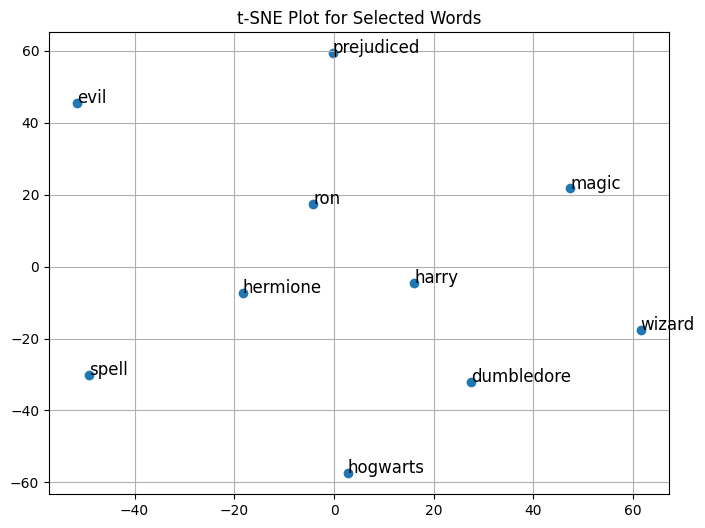

In [24]:
words = ["harry", "ron", "hermione", "dumbledore", "magic",
         "wizard", "spell", "hogwarts", "prejudiced", "evil"]

plot_specific_words(words)